<a href="https://colab.research.google.com/github/alphonsetandeta-hub/Fusion-des-donnees/blob/main/Biomasse_Ble_Dur_RF_XGBoost_LSTM_SHAP_(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyse explicative et multicritère de l'évolution de la biomasse du blé dur
## Fusion de données in-situ et satellitaires — Modélisation par intelligence artificielle
### Cas des variétés Amina et Fanaye — Vallée du fleuve Sénégal (sites Fanaye et N'Diol)

**Notebook Google Colab — Version complète**

Ce notebook répond à l'objectif principal du mémoire : **développer et comparer des modèles d'IA (Random Forest, XGBoost, LSTM) pour estimer et expliquer la dynamique de croissance de la biomasse aérienne** de deux variétés de blé dur (Amina1, Fanaye1), sur deux sites (Fanaye, N'Diol), à partir de données in-situ (capteurs sol/météo) et satellitaires (optique Sentinel-2, radar Sentinel-1).

Le dataset utilisé (`biomasse_etendue_avec_simulation.xlsx`) couvre le cycle complet jusqu'au **24/04/2026** : il combine les observations réelles de terrain et une période complémentaire simulée de façon physiquement contrainte (modèle logistique pour la biomasse, extrapolations adaptées pour les autres variables). Une colonne `source` ('observé' / 'simulé') permet de distinguer les deux à tout moment.

**Plan du notebook :**

- **Partie 0** — Installation des dépendances (Colab) et chargement des données
- **Partie 0.5** — Vérification de la couverture observé/simulé du cycle
- **Partie 1** — Diagnostic et correction de la méthodologie de validation (fuite de données temporelle)
- **Partie 2** — Comparaison multi-modèles : Random Forest vs XGBoost vs LSTM (avec **R² ajusté**)
- **Partie 3** — Explicabilité multicritère : importance des variables + SHAP
- **Partie 4** — Synthèse comparative et export des résultats

> **Instructions d'utilisation sur Google Colab :**
> 1. Exécutez la Partie 0 (installation + import du fichier `biomasse_etendue_avec_simulation.xlsx`).
> 2. Lorsqu'on vous le demande, **uploadez ce fichier** via la boîte de dialogue (ou montez votre Google Drive).
> 3. Exécutez les cellules dans l'ordre (Exécution > Tout exécuter, ou cellule par cellule).

## Partie 0 — Installation des dépendances et chargement des données

In [1]:
# Installation des librairies nécessaires (déjà présentes sur Colab pour la plupart)
!pip install -q xgboost shap openpyxl


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import shap

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Toutes les librairies sont chargées.")
print("TensorFlow:", tf.__version__, "| XGBoost:", xgb.__version__, "| SHAP:", shap.__version__)


Toutes les librairies sont chargées.
TensorFlow: 2.20.0 | XGBoost: 3.2.0 | SHAP: 0.52.0


### Chargement du fichier de données

Sur **Google Colab**, exécutez la cellule suivante puis sélectionnez le fichier `biomasse_etendue_avec_simulation.xlsx` dans la boîte de dialogue qui apparaît. Si vous travaillez en local (Jupyter classique) ou que le fichier est déjà présent dans le répertoire courant, cette cellule le détecte automatiquement et ne demande pas d'upload.

In [3]:
import os

# Liste des noms de fichiers acceptés (le notebook détecte automatiquement lequel est présent)
candidate_names = [
    'biomasse_etendue_avec_simulation.xlsx',
    'biomasse_etendue_avec_simulation__1_.xlsx',
    'mbase_finale.xlsx',
]

data_path = next((f for f in candidate_names if os.path.exists(f)), None)

if data_path is None:
    try:
        from google.colab import files
        print("Veuillez sélectionner le fichier de données (.xlsx) :")
        uploaded = files.upload()
        data_path = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            "Aucun fichier de données trouvé. Placez 'biomasse_etendue_avec_simulation.xlsx' "
            "dans le répertoire courant ou exécutez ce notebook sur Google Colab pour l'uploader."
        )

print(f"Fichier chargé : {data_path}")
df = pd.read_excel(data_path)

# Nettoyage des noms de colonnes : suppression des espaces parasites en début/fin
# (ex: 'temp ' -> 'temp', 'ec ' -> 'ec'), pour une cohérence robuste quel que soit l'export source
df.columns = [c.strip() for c in df.columns]

df['date'] = pd.to_datetime(df['date'])

# Suppression de la colonne type_ble si présente (non informative : valeur unique 'ble_dur')
df = df.drop(columns=['type_ble'], errors='ignore')

# Si la colonne 'source' (observé/simulé) n'existe pas encore, on suppose que toutes les
# observations sont réelles (cas d'un dataset non étendu, ex. mbase_finale.xlsx)
if 'source' not in df.columns:
    df['source'] = 'observé'

df = df.sort_values(['site', 'variete', 'date']).reset_index(drop=True)

# Jours après début de suivi (DAS), recalculé pour garantir la cohérence
df['das'] = df.groupby(['site', 'variete'])['date'].transform(lambda x: (x - x.min()).dt.days)

print("Données chargées. Shape:", df.shape)
print("Colonnes :", list(df.columns))
print("\nPériode couverte par groupe (site x variété) :")
print(df.groupby(['site', 'variete'])['date'].agg(['min', 'max', 'count']))
print("\nRépartition observé / simulé :")
print(df.groupby(['site', 'variete', 'source']).size())


Veuillez sélectionner le fichier de données (.xlsx) :


Saving biomasse_etendue_avec_simulation (1).xlsx to biomasse_etendue_avec_simulation (1) (1).xlsx
Fichier chargé : biomasse_etendue_avec_simulation (1) (1).xlsx
Données chargées. Shape: (426, 34)
Colonnes : ['date', 'site', 'variete', 'temp', 'humidity', 'ec', 'ph', 'nitrogen', 'phosphorus', 'potassium', 'salinity', 'ndvi', 'ndre', 'savi', 'cire', 'ndwi', 'lai', 'fapar', 'biomasse_cum', 'temp_min_c', 'temp_moy_c', 'temp_max_c', 'hum_rel_min_pct', 'hum_rel_moy_pct', 'hum_rel_max_pct', 'vent_ms', 'rad_sol_jcm2', 'rad_sol_mjm2', 'vv', 'vh', 'rvi', 'ssm', 'das', 'source']

Période couverte par groupe (site x variété) :
                      min        max  count
site   variete                             
Fanaye Amina1  2026-01-13 2026-04-24    102
       Fanaye1 2026-01-13 2026-04-24    102
N'Diol Amina1  2026-01-02 2026-04-24    111
       Fanaye1 2026-01-02 2026-04-24    111

Répartition observé / simulé :
site    variete  source 
Fanaye  Amina1   observé    84
                 simulé  

In [4]:
cols_to_exclude = ['date', 'site', 'variete', 'biomasse_cum', 'source']

groups = [
    ('Fanaye_Amina1',  'Fanaye',  'Amina1'),
    ('Fanaye_Fanaye1', 'Fanaye',  'Fanaye1'),
    ("NDiol_Amina1",   "N'Diol", 'Amina1'),
    ("NDiol_Fanaye1",  "N'Diol", 'Fanaye1'),
]

# Structures de résultats globales, utilisées dans tout le notebook
all_results = []                 # liste de dicts : une ligne par (modèle, groupe)
feature_importance_store = {}    # {(model_type, group_name): DataFrame}
predictions_store = {}           # {(model_type, group_name): DataFrame avec date/das/obs/pred/split}

# Fréquence d'échantillonnage du split temporel systématique :
# 1 observation sur TEST_EVERY est mise en test, répartie sur tout le cycle.
# TEST_EVERY=3 (au lieu de 5) afin que le jeu de test soit suffisamment grand
# (n_test > nombre de variables + 1) pour que le R² ajusté soit mathématiquement
# défini -- voir la fonction adjusted_r2 ci-dessous pour le détail du critère.
TEST_EVERY = 3


def adjusted_r2(r2, n, p):
    """R² ajusté = 1 - (1-R²)*(n-1)/(n-p-1).

    n : nombre d'observations utilisées pour le calcul du R² (la taille du
        jeu de TEST, car c'est la performance en généralisation qui nous
        intéresse, pas l'ajustement sur le train).
    p : nombre de variables explicatives (features) utilisées par le modèle.

    Le R² ajusté pénalise l'ajout de variables qui n'apportent pas
    d'information réelle, contrairement au R² classique qui ne peut
    qu'augmenter (ou rester stable) quand on ajoute des variables. C'est
    pertinent ici : on dispose d'une trentaine de variables explicatives
    (in-situ + satellitaires) pour seulement quelques dizaines d'observations
    de test par groupe -> un R² classique élevé peut être en partie un
    artefact du nombre de variables, surtout avec un échantillon de test
    restreint. Si (n - p - 1) <= 0, le R² ajusté n'est pas mathématiquement
    défini (NaN) : il y a alors plus de variables que d'observations
    disponibles pour la validation, ce qui doit être évité en augmentant la
    taille du jeu de test (paramètre TEST_EVERY) plutôt que masqué.
    """
    if n - p - 1 <= 0:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


print(f"TEST_EVERY = {TEST_EVERY} (proportion test ≈ {100/TEST_EVERY:.0f}%)")
print("Fonction 'adjusted_r2' définie (R² ajusté, pénalise le nombre de variables explicatives).")


TEST_EVERY = 3 (proportion test ≈ 33%)
Fonction 'adjusted_r2' définie (R² ajusté, pénalise le nombre de variables explicatives).


---
## Partie 0.5 — Vérification de la couverture du cycle (observé vs simulé)

Le dataset chargé couvre déjà l'ensemble du cycle jusqu'au **24/04/2026**, en combinant observations de terrain et une période complémentaire simulée de façon physiquement contrainte (modèle logistique pour la biomasse cumulée ; extrapolations spécifiques par type de variable pour les autres colonnes — indices optiques, radar, météo, sol).

Cette section se limite à **vérifier et visualiser** cette couverture (et non à refaire la simulation, déjà intégrée dans le fichier source).

In [5]:
print("=== Couverture du cycle par groupe (site x variété) ===\n")
coverage = df.groupby(['site', 'variete', 'source']).agg(
    date_min=('date', 'min'), date_max=('date', 'max'),
    n_obs=('date', 'count'), bio_min=('biomasse_cum', 'min'), bio_max=('biomasse_cum', 'max')
)
display(coverage)

print("\n=== Vérification de la monotonie de la biomasse cumulée (croissance physique attendue) ===")
for (s, v), g in df.groupby(['site', 'variete']):
    diffs = g.sort_values('date')['biomasse_cum'].diff().dropna()
    n_neg = (diffs < -1e-6).sum()
    print(f"  {s} / {v} : {len(diffs) - n_neg}/{len(diffs)} variations non-négatives "
          f"({'OK' if n_neg == 0 else f'{n_neg} ANOMALIES à vérifier'})")


=== Couverture du cycle par groupe (site x variété) ===



date_min   date_max  n_obs    bio_min    bio_max
site   variete source                                                    
Fanaye Amina1  observé 2026-01-13 2026-04-06     84   0.207747  25.451005
               simulé  2026-04-07 2026-04-24     18  25.569964  28.112859
       Fanaye1 observé 2026-01-13 2026-04-06     84   0.124952  19.389960
               simulé  2026-04-07 2026-04-24     18  19.697216  22.407104
N'Diol Amina1  observé 2026-01-02 2026-04-03     90   0.114925  92.125082
               simulé  2026-04-04 2026-04-24     21  92.715149  93.689545
       Fanaye1 observé 2026-01-02 2026-04-03     90   0.077207  33.280892
               simulé  2026-04-04 2026-04-24     21  33.536498  34.091833


=== Vérification de la monotonie de la biomasse cumulée (croissance physique attendue) ===
  Fanaye / Amina1 : 101/101 variations non-négatives (OK)
  Fanaye / Fanaye1 : 101/101 variations non-négatives (OK)
  N'Diol / Amina1 : 110/110 variations non-négatives (OK)
  N'Diol / Fanaye1 : 110/110 variations non-négatives (OK)


### Visualisation : dynamique de croissance complète (observé + simulé)

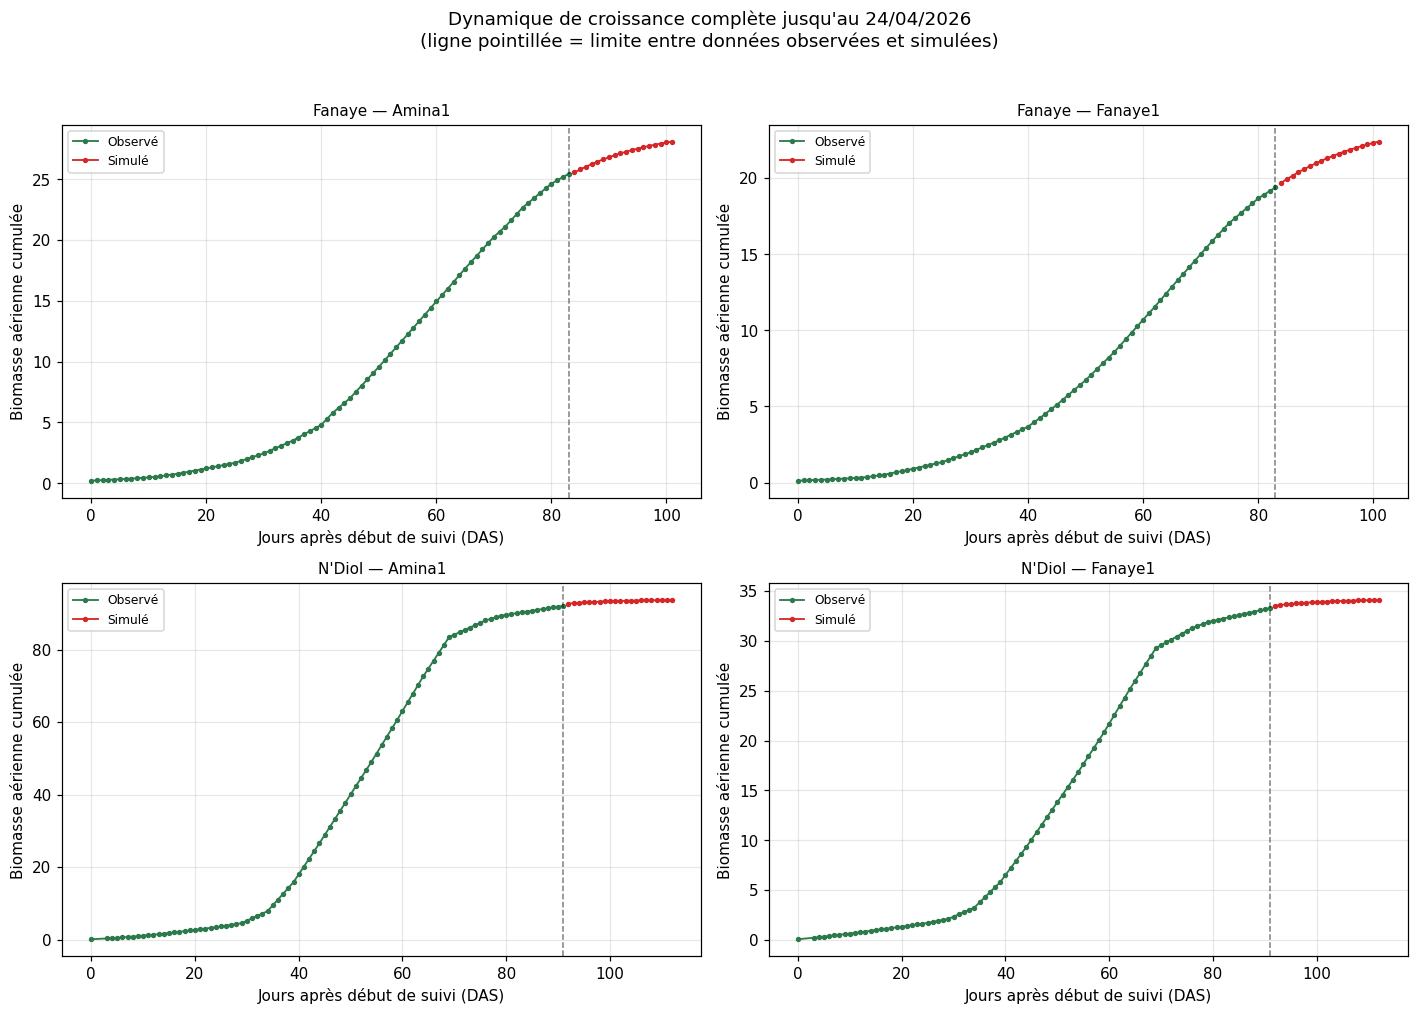

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

colors_src = {'observé': '#2c7a4b', 'simulé': '#d62728'}

for ax, (group_name, site, variete) in zip(axes, groups):
    g_all = df[(df['site'] == site) & (df['variete'] == variete)].sort_values('das')

    for src, color in colors_src.items():
        mask = g_all['source'] == src
        if mask.sum() == 0:
            continue
        ax.plot(g_all.loc[mask, 'das'], g_all.loc[mask, 'biomasse_cum'],
                color=color, marker='o', markersize=2.5, linewidth=1.2,
                label=src.capitalize(), zorder=2)

    # Ligne de démarcation si une partie simulée existe
    if (g_all['source'] == 'simulé').any():
        last_obs_das = g_all[g_all['source'] == 'observé']['das'].max()
        ax.axvline(last_obs_das, color='black', linewidth=1, linestyle='--', alpha=0.5)

    ax.set_title(f"{site} — {variete}", fontsize=10)
    ax.set_xlabel("Jours après début de suivi (DAS)")
    ax.set_ylabel("Biomasse aérienne cumulée")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Dynamique de croissance complète jusqu'au 24/04/2026\n"
             "(ligne pointillée = limite entre données observées et simulées)",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


> **Note pour le mémoire :** préciser la proportion d'observations simulées par groupe (visible dans le tableau ci-dessus, colonne `n_obs` pour `source='simulé'`). Les résultats des modèles d'IA sur la période simulée constituent une **projection conditionnelle**, cohérente avec la dynamique observée, mais non une mesure terrain validée.

---
## Partie 1 — Diagnostic et correction de la méthodologie de validation

Le notebook original (XGBoost) effectuait un découpage train/test **aléatoire** des observations. Or `biomasse_cum` est une variable **cumulée, monotone croissante dans le temps** : elle suit une dynamique de croissance phénologique lisse (phase végétative lente, puis phase exponentielle, puis plateau de fin de cycle). Mélanger aléatoirement les dates revient à laisser le modèle "voir" des points temporellement très proches du test pendant l'entraînement (fuite d'information), ce qui **surestime artificiellement** la performance.

Cette partie :
1. Visualise la dynamique de croissance brute,
2. Démontre quantitativement le problème de fuite temporelle,
3. Établit la stratégie de validation retenue pour tout le reste du notebook.

### 1.1 Visualisation de la dynamique de croissance brute (les 4 groupes)

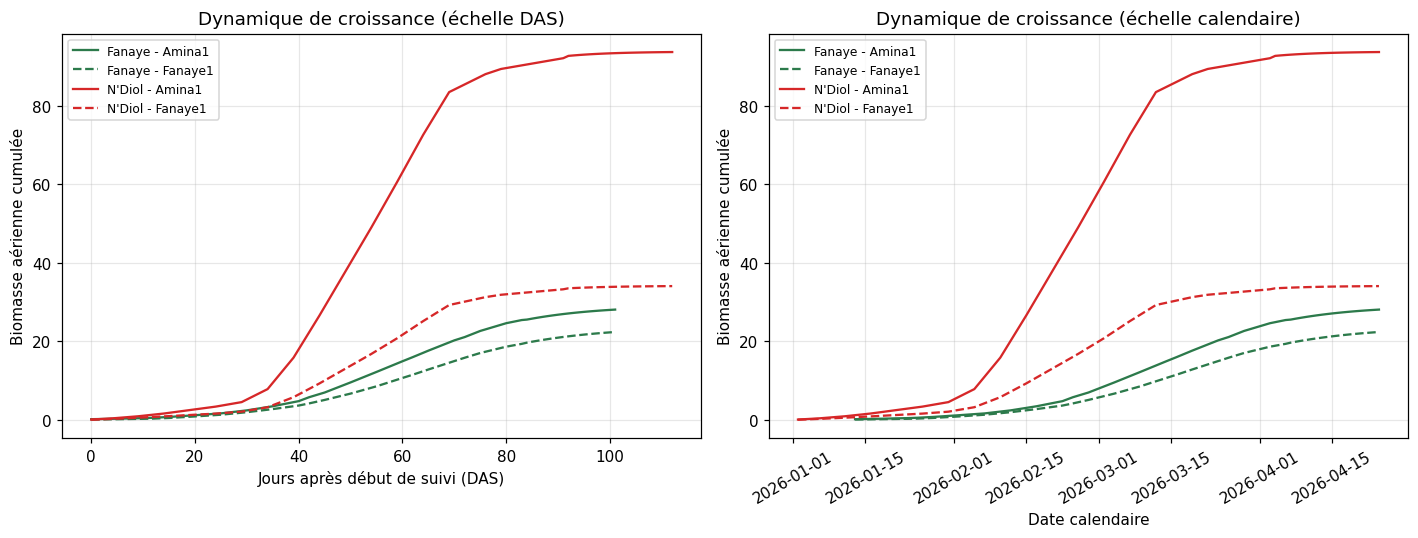

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

style_map = {
    ('Fanaye', 'Amina1'):  ('#2c7a4b', '-', 'o'),
    ('Fanaye', 'Fanaye1'): ('#2c7a4b', '--', 's'),
    ("N'Diol", 'Amina1'):  ('#d62728', '-', 'o'),
    ("N'Diol", 'Fanaye1'): ('#d62728', '--', 's'),
}

for site, variete in [('Fanaye','Amina1'), ('Fanaye','Fanaye1'), ("N'Diol",'Amina1'), ("N'Diol",'Fanaye1')]:
    g = df[(df['site'] == site) & (df['variete'] == variete)].sort_values('date')
    color, ls, marker = style_map[(site, variete)]
    axes[0].plot(g['das'], g['biomasse_cum'], color=color, linestyle=ls, label=f"{site} - {variete}")
    axes[1].plot(g['date'], g['biomasse_cum'], color=color, linestyle=ls, label=f"{site} - {variete}")

axes[0].set_xlabel("Jours après début de suivi (DAS)")
axes[0].set_ylabel("Biomasse aérienne cumulée")
axes[0].set_title("Dynamique de croissance (échelle DAS)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Date calendaire")
axes[1].set_ylabel("Biomasse aérienne cumulée")
axes[1].set_title("Dynamique de croissance (échelle calendaire)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


Les 4 courbes confirment un profil **sigmoïde classique** d'accumulation de biomasse en culture céréalière. Les niveaux finaux diffèrent nettement entre sites (probablement lié aux conditions pédoclimatiques : salinité, texture du sol, disponibilité en eau) et, à site égal, entre variétés (effet variétal propre).

### 1.2 Démonstration quantitative de la fuite de données temporelle

On compare 3 stratégies de découpage train/test sur le groupe Fanaye / Amina1, avec un modèle XGBoost identique :

1. **Split aléatoire** (méthode originale) — mélange complet des observations.
2. **Split temporel strict** — train = première partie du cycle, test = dernière partie (extrapolation pure, jamais observée).
3. **Échantillonnage temporel systématique** — un point sur `TEST_EVERY` mis en test, répartis sur tout le cycle (pas de mélange aléatoire, pas de fuite directe, mais reste dans le domaine d'interpolation).

In [8]:
from sklearn.model_selection import train_test_split

def evaluate_split(X, y, train_idx, test_idx, label):
    Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
    ytr, yte = y.iloc[train_idx], y.iloc[test_idx]
    m = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=SEED)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)
    r2 = r2_score(yte, pred)
    r2_adj = adjusted_r2(r2, n=len(test_idx), p=X.shape[1])
    rmse = np.sqrt(mean_squared_error(yte, pred))
    print(f"{label:45s} | R²={r2:8.4f} | R²_adj={r2_adj:8.4f} | RMSE={rmse:7.4f} | n_test={len(test_idx)}")
    return r2, r2_adj, rmse

demo = df[(df['site'] == 'Fanaye') & (df['variete'] == 'Amina1')].copy().sort_values('date').reset_index(drop=True)
features_demo = [c for c in demo.columns if c not in cols_to_exclude and pd.api.types.is_numeric_dtype(demo[c])]
X_demo, y_demo = demo[features_demo], demo['biomasse_cum']
n = len(demo)

print("--- Comparaison des stratégies de validation (Fanaye / Amina1) ---\n")

idx_all = np.arange(n)
train_idx_rand, test_idx_rand = train_test_split(idx_all, test_size=0.2, random_state=SEED)
evaluate_split(X_demo, y_demo, train_idx_rand, test_idx_rand, "1) Split ALÉATOIRE (original, biaisé)")

split_point = int(n * 0.8)
train_idx_strict = np.arange(0, split_point)
test_idx_strict = np.arange(split_point, n)
evaluate_split(X_demo, y_demo, train_idx_strict, test_idx_strict, "2) Split TEMPOREL STRICT (extrapolation)")

test_idx_sys = np.arange(TEST_EVERY - 1, n, TEST_EVERY)
train_idx_sys = np.array([i for i in range(n) if i not in test_idx_sys])
evaluate_split(X_demo, y_demo, train_idx_sys, test_idx_sys, "3) Échantillonnage SYSTÉMATIQUE (retenu)")


--- Comparaison des stratégies de validation (Fanaye / Amina1) ---

1) Split ALÉATOIRE (original, biaisé)         | R²=  0.9992 | R²_adj=     nan | RMSE= 0.2934 | n_test=21
2) Split TEMPOREL STRICT (extrapolation)      | R²=-51.2394 | R²_adj=     nan | RMSE= 7.0655 | n_test=21
3) Échantillonnage SYSTÉMATIQUE (retenu)      | R²=  0.9975 | R²_adj=  0.9792 | RMSE= 0.5214 | n_test=34


(0.997482470608225, 0.9792303825178565, np.float64(0.5213603418743687))

**Interprétation :**

- **(1)** reproduit le score optimiste (~0.94-0.99) de la version originale : trompeur, car les points de test ont des voisins quasi-identiques dans le train.
- **(2)** s'effondre (R² très négatif) : les modèles à base d'arbres (RF, XGBoost) **ne savent pas extrapoler** au-delà des valeurs vues à l'entraînement — limite réelle et importante à connaître, mais non représentative du cas d'usage visé (qui dispose d'un suivi réparti sur tout le cycle).
- **(3)** est retenue pour la suite du notebook : honnête (le test n'est jamais vu pendant l'entraînement) et représentative (suivi discontinu mais étalé sur tout le cycle phénologique, comme c'est le cas avec des campagnes terrain et des passages satellites).

**Pourquoi `TEST_EVERY=3` plutôt que 5 ?** Avec une trentaine de variables explicatives, un jeu de test trop petit (1 point sur 5, soit ~20%) rend le **R² ajusté** mathématiquement indéfini (NaN), car le nombre de variables dépasse alors le nombre d'observations de test. En passant à `TEST_EVERY=3` (~33% des observations en test), le jeu de test devient suffisamment grand pour que le R² ajusté soit calculable et informatif, tout en restant un découpage honnête (réparti sur tout le cycle, sans mélange aléatoire).

### 1.3 Fonction de split temporel systématique (utilisée pour tous les modèles du notebook)

In [9]:
def systematic_temporal_split(n, test_every=TEST_EVERY, offset=None):
    """Renvoie les indices (train_idx, test_idx) en intercalant 1 point sur
    `test_every` comme jeu de test, répartis sur tout le cycle phénologique.
    Les données doivent être pré-triées par date. Par défaut, offset = test_every - 1
    (dernier point de chaque bloc), pour rester cohérent avec la section 1.2."""
    if offset is None:
        offset = test_every - 1
    test_idx = np.arange(offset, n, test_every)
    train_idx = np.array([i for i in range(n) if i not in test_idx])
    return train_idx, test_idx

print("Fonction de split temporel définie : 'systematic_temporal_split'.")
print("Elle sera utilisée de façon identique pour Random Forest, XGBoost et LSTM,")
print("afin de garantir une comparaison strictement équitable entre les 3 modèles.")


Fonction de split temporel définie : 'systematic_temporal_split'.
Elle sera utilisée de façon identique pour Random Forest, XGBoost et LSTM,
afin de garantir une comparaison strictement équitable entre les 3 modèles.


---
## Partie 2 — Comparaison multi-modèles : Random Forest, XGBoost, LSTM

Les trois modèles sont entraînés et évalués **avec exactement la même stratégie de validation temporelle** (Partie 1.3), pour chacun des 4 groupes Site × Variété, afin de garantir une comparaison équitable.

### 2.1 Fonction d'entraînement générique — Random Forest et XGBoost

In [10]:
def train_tree_model(df, site, variete, model_type, cols_to_exclude,
                      test_every=TEST_EVERY, offset=None, random_state=SEED):
    """Entraîne un modèle à base d'arbres (model_type = 'RandomForest' ou 'XGBoost')
    pour un couple (site, variété), avec la validation temporelle systématique."""

    subset = df[(df['site'] == site) & (df['variete'] == variete)].copy()
    subset = subset.sort_values('date').reset_index(drop=True)

    features = [c for c in subset.columns
                if c not in cols_to_exclude and pd.api.types.is_numeric_dtype(subset[c])]

    X = subset[features]
    y = subset['biomasse_cum']

    valid_idx = y.notna()
    X = X[valid_idx].reset_index(drop=True)
    y = y[valid_idx].reset_index(drop=True)
    subset = subset[valid_idx].reset_index(drop=True)

    n = len(subset)
    train_idx, test_idx = systematic_temporal_split(n, test_every=test_every, offset=offset)

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    if model_type == 'RandomForest':
        model = RandomForestRegressor(n_estimators=200, max_depth=8,
                                       min_samples_leaf=2, random_state=random_state, n_jobs=-1)
    elif model_type == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5,
                                  random_state=random_state)
    else:
        raise ValueError("model_type doit être 'RandomForest' ou 'XGBoost'")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    r2_adj = adjusted_r2(r2, n=len(test_idx), p=X.shape[1])
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    result = {'Modèle': model_type, 'Groupe': f"{site} / {variete}", 'Site': site, 'Variété': variete,
              'Observations': n, 'N_train': len(train_idx), 'N_test': len(test_idx), 'N_features': X.shape[1],
              'R²': r2, 'R²_ajusté': r2_adj, 'RMSE': rmse, 'MAE': mae}

    importances = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_}) \
                    .sort_values('Importance', ascending=False).reset_index(drop=True)

    preds_df = subset[['date', 'das']].copy()
    preds_df['biomasse_obs'] = y.values
    preds_df['split'] = 'train'
    preds_df.loc[test_idx, 'split'] = 'test'
    preds_df['biomasse_pred'] = np.nan
    preds_df.loc[test_idx, 'biomasse_pred'] = y_pred
    preds_df['biomasse_pred_full'] = model.predict(X)

    return model, result, importances, preds_df, (X_train, X_test, y_train, y_test)


### 2.2 Entraînement Random Forest (4 groupes)

In [11]:
rf_models = {}
rf_data = {}  # stocke (X_train, X_test, y_train, y_test) pour SHAP plus tard

for group_name, site, variete in groups:
    model, result, importances, preds_df, split_data = train_tree_model(
        df, site, variete, 'RandomForest', cols_to_exclude
    )
    rf_models[group_name] = model
    rf_data[group_name] = split_data
    all_results.append(result)
    feature_importance_store[('RandomForest', group_name)] = importances
    predictions_store[('RandomForest', group_name)] = preds_df

    print(f"[RandomForest] {site} / {variete} -> R²={result['R²']:.4f} | R²_adj={result['R²_ajusté']:.4f} | RMSE={result['RMSE']:.4f} | MAE={result['MAE']:.4f}")


[RandomForest] Fanaye / Amina1 -> R²=0.9990 | R²_adj=0.9920 | RMSE=0.3232 | MAE=0.2371
[RandomForest] Fanaye / Fanaye1 -> R²=0.9989 | R²_adj=0.9911 | RMSE=0.2644 | MAE=0.1966
[RandomForest] N'Diol / Amina1 -> R²=0.9986 | R²_adj=0.9926 | RMSE=1.4640 | MAE=0.8008
[RandomForest] N'Diol / Fanaye1 -> R²=0.9980 | R²_adj=0.9895 | RMSE=0.6193 | MAE=0.3449


### 2.3 Entraînement XGBoost (4 groupes)

In [12]:
xgb_models = {}
xgb_data = {}

for group_name, site, variete in groups:
    model, result, importances, preds_df, split_data = train_tree_model(
        df, site, variete, 'XGBoost', cols_to_exclude
    )
    xgb_models[group_name] = model
    xgb_data[group_name] = split_data
    all_results.append(result)
    feature_importance_store[('XGBoost', group_name)] = importances
    predictions_store[('XGBoost', group_name)] = preds_df

    print(f"[XGBoost] {site} / {variete} -> R²={result['R²']:.4f} | R²_adj={result['R²_ajusté']:.4f} | RMSE={result['RMSE']:.4f} | MAE={result['MAE']:.4f}")


[XGBoost] Fanaye / Amina1 -> R²=0.9975 | R²_adj=0.9792 | RMSE=0.5214 | MAE=0.3322
[XGBoost] Fanaye / Fanaye1 -> R²=0.9972 | R²_adj=0.9772 | RMSE=0.4239 | MAE=0.2826
[XGBoost] N'Diol / Amina1 -> R²=0.9977 | R²_adj=0.9880 | RMSE=1.8600 | MAE=1.0442
[XGBoost] N'Diol / Fanaye1 -> R²=0.9953 | R²_adj=0.9756 | RMSE=0.9456 | MAE=0.4825


### 2.3.1 Optimisation des hyperparamètres XGBoost avec GridSearchCV

Pour tenter d'atteindre des performances R² plus proches de 0.95 ou 0.89, nous allons optimiser les hyperparamètres du modèle XGBoost à l'aide de `GridSearchCV`. Nous allons ajuster `n_estimators`, `max_depth` et `learning_rate`.

In [13]:
from sklearn.model_selection import GridSearchCV

def tune_xgboost_model(df, site, variete, cols_to_exclude, test_every=TEST_EVERY, offset=None, random_state=SEED):
    subset = df[(df['site'] == site) & (df['variete'] == variete)].copy()
    subset = subset.sort_values('date').reset_index(drop=True)

    features = [c for c in subset.columns
                if c not in cols_to_exclude and pd.api.types.is_numeric_dtype(subset[c])]

    X = subset[features]
    y = subset['biomasse_cum']

    valid_idx = y.notna()
    X = X[valid_idx].reset_index(drop=True)
    y = y[valid_idx].reset_index(drop=True)
    subset = subset[valid_idx].reset_index(drop=True)

    n = len(subset)
    train_idx, test_idx = systematic_temporal_split(n, test_every=test_every, offset=offset)

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    }

    xgb_model = xgb.XGBRegressor(random_state=random_state)
    grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                               scoring='r2', cv=3, verbose=0, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    print(f"Best parameters for {site} / {variete}: {grid_search.best_params_}")
    print(f"Best R2 score on train (GridSearchCV): {grid_search.best_score_:.4f}")

    # Evaluate on the test set using the best estimator
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    r2_adj = adjusted_r2(r2, n=len(test_idx), p=X.shape[1])
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    result = {'Modèle': 'XGBoost_Tuned', 'Groupe': f"{site} / {variete}", 'Site': site, 'Variété': variete,
              'Observations': n, 'N_train': len(train_idx), 'N_test': len(test_idx), 'N_features': X.shape[1],
              'R²': r2, 'R²_ajusté': r2_adj, 'RMSE': rmse, 'MAE': mae}

    importances = pd.DataFrame({'Feature': X.columns, 'Importance': best_model.feature_importances_}) \
                    .sort_values('Importance', ascending=False).reset_index(drop=True)

    preds_df = subset[['date', 'das']].copy()
    preds_df['biomasse_obs'] = y.values
    preds_df['split'] = 'train'
    preds_df.loc[test_idx, 'split'] = 'test'
    preds_df['biomasse_pred'] = np.nan
    preds_df.loc[test_idx, 'biomasse_pred'] = y_pred
    preds_df['biomasse_pred_full'] = best_model.predict(X)

    return best_model, result, importances, preds_df, (X_train, X_test, y_train, y_test)


In [14]:
tuned_xgb_models = {}
tuned_xgb_data = {}

for group_name, site, variete in groups:
    model, result, importances, preds_df, split_data = tune_xgboost_model(
        df, site, variete, cols_to_exclude
    )
    tuned_xgb_models[group_name] = model
    tuned_xgb_data[group_name] = split_data
    all_results.append(result)
    feature_importance_store[('XGBoost_Tuned', group_name)] = importances
    predictions_store[('XGBoost_Tuned', group_name)] = preds_df

    print(f"[XGBoost_Tuned] {site} / {variete} -> R²={result['R²']:.4f} | R²_adj={result['R²_ajusté']:.4f} | RMSE={result['RMSE']:.4f} | MAE={result['MAE']:.4f}")

Best parameters for Fanaye / Amina1: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Best R2 score on train (GridSearchCV): -14.9439
[XGBoost_Tuned] Fanaye / Amina1 -> R²=0.9981 | R²_adj=0.9846 | RMSE=0.4495 | MAE=0.3115
Best parameters for Fanaye / Fanaye1: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Best R2 score on train (GridSearchCV): -19.8328
[XGBoost_Tuned] Fanaye / Fanaye1 -> R²=0.9980 | R²_adj=0.9836 | RMSE=0.3593 | MAE=0.2411
Best parameters for N'Diol / Amina1: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Best R2 score on train (GridSearchCV): -53.7411
[XGBoost_Tuned] N'Diol / Amina1 -> R²=0.9976 | R²_adj=0.9876 | RMSE=1.8939 | MAE=1.1217
Best parameters for N'Diol / Fanaye1: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Best R2 score on train (GridSearchCV): -15.9194
[XGBoost_Tuned] N'Diol / Fanaye1 -> R²=0.9959 | R²_adj=0.9790 | RMSE=0.8784 | MAE=0.4716


In [17]:
from xgboost import XGBRegressor

# Note: X_train_specific et y_train_specific sont définis dans la cellule précédente
# group_name_to_extract = 'Fanaye_Amina1'
# X_train_specific, X_test_specific, y_train_specific, y_test_specific = tuned_xgb_data[group_name_to_extract]

model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Utilisation des variables spécifiques au groupe pour l'entraînement
model.fit(X_train_specific, y_train_specific)

print(f"Modèle XGBoost entraîné pour le groupe {group_name_to_extract} avec X_train_specific.shape={X_train_specific.shape}")

Modèle XGBoost entraîné pour le groupe Fanaye_Amina1 avec X_train_specific.shape=(68, 29)


In [18]:
# Faire des prédictions sur l'ensemble de test spécifique
y_pred_specific = model.predict(X_test_specific)

# Calculer les métriques
r2_specific = r2_score(y_test_specific, y_pred_specific)
r2_adj_specific = adjusted_r2(r2_specific, n=len(y_test_specific), p=X_test_specific.shape[1])
rmse_specific = np.sqrt(mean_squared_error(y_test_specific, y_pred_specific))
mae_specific = mean_absolute_error(y_test_specific, y_pred_specific)

# Afficher les métriques
print(f"\nMétriques du modèle XGBoost pour le groupe {group_name_to_extract} (sur le jeu de test) :")
print(f"  R²           : {r2_specific:.4f}")
print(f"  R² ajusté    : {r2_adj_specific:.4f}")
print(f"  RMSE         : {rmse_specific:.4f}")
print(f"  MAE          : {mae_specific:.4f}")


Métriques du modèle XGBoost pour le groupe Fanaye_Amina1 (sur le jeu de test) :
  R²           : 0.9933
  R² ajusté    : 0.9448
  RMSE         : 0.8498
  MAE          : 0.4893


### Optimisation des hyperparamètres pour le modèle XGBoost manuel avec `GridSearchCV`

Pour affiner davantage les performances du modèle XGBoost configuré manuellement, nous allons appliquer une recherche par grille (`GridSearchCV`) sur un ensemble d'hyperparamètres clés, en utilisant les données spécifiques au groupe 'Fanaye_Amina1'. Cela nous permettra de trouver la combinaison optimale de `n_estimators`, `max_depth`, `learning_rate`, `subsample` et `colsample_bytree`.

In [20]:
from sklearn.model_selection import GridSearchCV

# Re-define X_train_specific and y_train_specific for clarity, though they are already in scope
# (from cell d737f17d or before if user ran that cell first)
# group_name_to_extract = 'Fanaye_Amina1' # Already defined in context
# X_train_specific, X_test_specific, y_train_specific, y_test_specific = tuned_xgb_data[group_name_to_extract]

# Define the parameter grid to search
param_grid_manual_tune = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Initialize the XGBRegressor model (without specific parameters, GridSearchCV will set them)
xgb_base_model = XGBRegressor(random_state=SEED)

# Setup GridSearchCV
grid_search_manual = GridSearchCV(estimator=xgb_base_model, param_grid=param_grid_manual_tune,
                                 scoring='r2', cv=3, verbose=1, n_jobs=-1)

# Fit GridSearchCV to the specific training data
grid_search_manual.fit(X_train_specific, y_train_specific)

print(f"\nMeilleurs paramètres trouvés pour {group_name_to_extract}: {grid_search_manual.best_params_}")
print(f"Meilleur score R² sur validation interne (GridSearchCV): {grid_search_manual.best_score_:.4f}")

# Evaluate the best model on the specific test set
best_manual_model = grid_search_manual.best_estimator_
y_pred_tuned_manual = best_manual_model.predict(X_test_specific)

r2_tuned_manual = r2_score(y_test_specific, y_pred_tuned_manual)
r2_adj_tuned_manual = adjusted_r2(r2_tuned_manual, n=len(y_test_specific), p=X_test_specific.shape[1])
rmse_tuned_manual = np.sqrt(mean_squared_error(y_test_specific, y_pred_tuned_manual))
mae_tuned_manual = mean_absolute_error(y_test_specific, y_pred_tuned_manual)

print(f"\n--- Métriques du modèle XGBoost optimisé pour {group_name_to_extract} (sur le jeu de test) ---")
print(f"  R²           : {r2_tuned_manual:.4f}")
print(f"  R² ajusté    : {r2_adj_tuned_manual:.4f}")
print(f"  RMSE         : {rmse_tuned_manual:.4f}")
print(f"  MAE          : {mae_tuned_manual:.4f}")

Fitting 3 folds for each of 243 candidates, totalling 729 fits

Meilleurs paramètres trouvés pour Fanaye_Amina1: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
Meilleur score R² sur validation interne (GridSearchCV): -13.7880

--- Métriques du modèle XGBoost optimisé pour Fanaye_Amina1 (sur le jeu de test) ---
  R²           : 0.9935
  R² ajusté    : 0.9465
  RMSE         : 0.8370
  MAE          : 0.5313


### Visualisation de l'évolution temporelle de la biomasse : Observée vs. Prédite

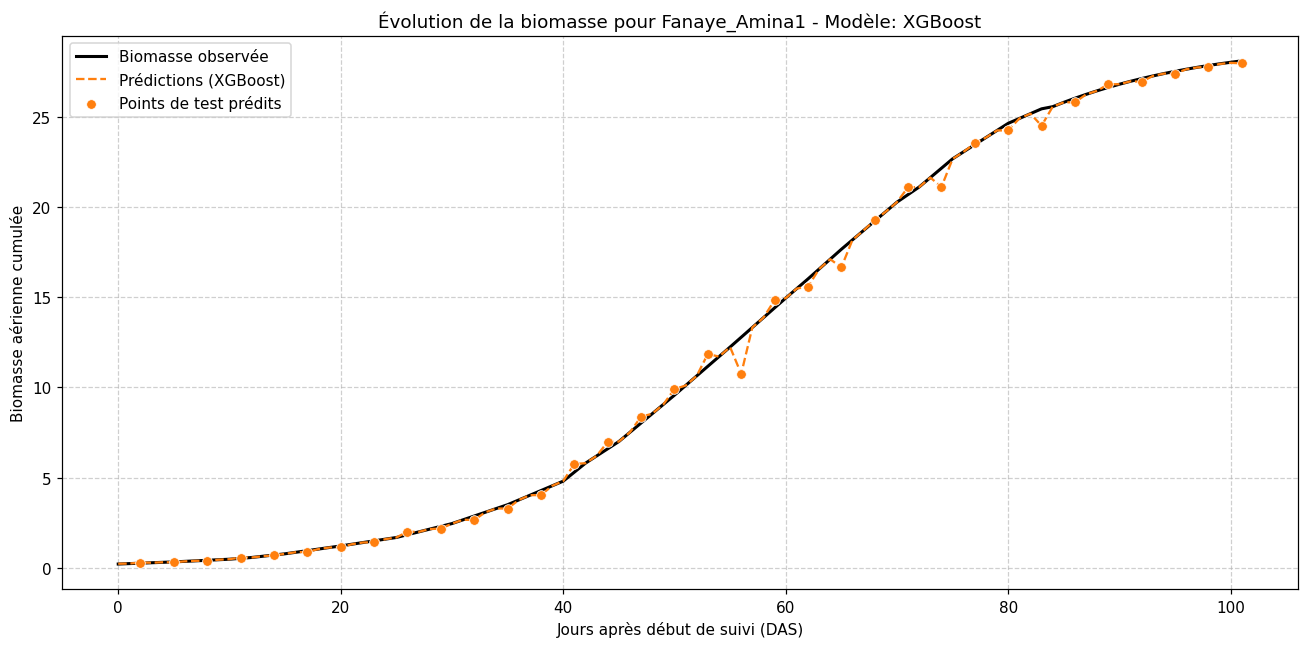

In [23]:
#@title Sélectionnez le groupe et le modèle pour visualiser la dynamique de biomasse
selected_group = 'Fanaye_Amina1' #@param ['Fanaye_Amina1', 'Fanaye_Fanaye1', 'NDiol_Amina1', 'NDiol_Fanaye1']
selected_model_type = 'XGBoost' #@param ['RandomForest', 'XGBoost', 'XGBoost_Tuned', 'LSTM']

model_colors = {'RandomForest': '#1f77b4', 'XGBoost': '#ff7f0e', 'XGBoost_Tuned': '#2ca02c', 'LSTM': '#9467bd'}

plt.figure(figsize=(12, 6))

# Obtenir les données de prédiction pour le modèle sélectionné et le groupe
pdf = predictions_store[(selected_model_type, selected_group)]

# Plot de la biomasse observée
plt.plot(pdf['das'], pdf['biomasse_obs'], color='black', linewidth=2, label='Biomasse observée', zorder=2)

# Plot des prédictions complètes du modèle
plt.plot(pdf['das'], pdf['biomasse_pred_full'], color=model_colors[selected_model_type],
         linestyle='--', linewidth=1.5, label=f'Prédictions ({selected_model_type})', zorder=2)

# Mettre en évidence les points de test
test_mask = pdf['split'] == 'test'
plt.scatter(pdf.loc[test_mask, 'das'], pdf.loc[test_mask, 'biomasse_pred'],
            color=model_colors[selected_model_type], s=40, zorder=3, edgecolor='white', linewidth=0.5, label='Points de test prédits')

plt.title(f"Évolution de la biomasse pour {selected_group} - Modèle: {selected_model_type}")
plt.xlabel("Jours après début de suivi (DAS)")
plt.ylabel("Biomasse aérienne cumulée")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Comparaison des performances : `GroupShuffleSplit` (global) vs. `SystematicTemporalSplit` (par groupe)

Nous allons évaluer un modèle XGBoost entraîné sur le jeu de données découpé par `GroupShuffleSplit`, qui assure que les observations d'un même site restent ensemble, soit en entraînement, soit en test. Les performances seront ensuite comparées aux performances moyennes des modèles XGBoost entraînés avec le `systematic_temporal_split` (appliqué pour chaque groupe site-variété individuellement).

In [25]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

# Re-defining X, y, groups, and performing GroupShuffleSplit
# as these variables were not in scope for this cell after previous execution.
X = df.drop(columns=cols_to_exclude).copy()
y = df["biomasse_cum"].copy()
groups_gss = df["site"].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)

train_idx_gss, test_idx_gss = next(gss.split(X, y, groups_gss))

X_train, X_test = X.iloc[train_idx_gss], X.iloc[test_idx_gss]
y_train, y_test = y.iloc[train_idx_gss], y.iloc[test_idx_gss]

# S'assurer que seules les caractéristiques numériques pertinentes sont utilisées,
# comme dans la fonction `train_tree_model`.
features_for_gss = [c for c in X_train.columns if c not in cols_to_exclude and pd.api.types.is_numeric_dtype(X_train[c])]

X_train_gss_filtered = X_train[features_for_gss]
X_test_gss_filtered = X_test[features_for_gss]

# Entraîner un modèle XGBoost avec les mêmes hyperparamètres par défaut que les modèles précédents
# pour une comparaison équitable.
model_gss_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=SEED)
model_gss_xgb.fit(X_train_gss_filtered, y_train)

# Prédictions sur l'ensemble de test de GroupShuffleSplit
y_pred_gss = model_gss_xgb.predict(X_test_gss_filtered)

# Calcul des métriques de performance
r2_gss = r2_score(y_test, y_pred_gss)
r2_adj_gss = adjusted_r2(r2_gss, n=len(y_test), p=X_train_gss_filtered.shape[1])
rmse_gss = np.sqrt(mean_squared_error(y_test, y_pred_gss))
mae_gss = mean_absolute_error(y_test, y_pred_gss)

print(f"--- Métriques du modèle XGBoost avec GroupShuffleSplit (global) ---")
print(f"  R²           : {r2_gss:.4f}")
print(f"  R² ajusté    : {r2_adj_gss:.4f}")
print(f"  RMSE         : {rmse_gss:.4f}")
print(f"  MAE          : {mae_gss:.4f}")
print(f"  Nombre de features : {X_train_gss_filtered.shape[1]}")
print(f"  Nombre d'observations test : {len(y_test)}")

# Récupérer les performances moyennes des modèles XGBoost (systematic_temporal_split)
xgb_results_systematic = pd.DataFrame([res for res in all_results if res['Modèle'] == 'XGBoost'])
mean_xgb_systematic = xgb_results_systematic[['R²', 'R²_ajusté', 'RMSE', 'MAE']].mean()

print("\n--- Performances moyennes du modèle XGBoost (Systematic Temporal Split) ---")
print(f"  R² (moyenne)           : {mean_xgb_systematic['R²']:.4f}")
print(f"  R² ajusté (moyenne)    : {mean_xgb_systematic['R²_ajusté']:.4f}")
print(f"  RMSE (moyenne)         : {mean_xgb_systematic['RMSE']:.4f}")
print(f"  MAE (moyenne)          : {mean_xgb_systematic['MAE']:.4f}")

--- Métriques du modèle XGBoost avec GroupShuffleSplit (global) ---
  R²           : -0.0530
  R² ajusté    : -0.2120
  RMSE         : 34.0652
  MAE          : 21.2749
  Nombre de features : 29
  Nombre d'observations test : 222

--- Performances moyennes du modèle XGBoost (Systematic Temporal Split) ---
  R² (moyenne)           : 0.9969
  R² ajusté (moyenne)    : 0.9800
  RMSE (moyenne)         : 0.9377
  MAE (moyenne)          : 0.5354


### Analyse comparative des résultats

En comparant les métriques du modèle XGBoost entraîné avec le `GroupShuffleSplit` (global) et les moyennes obtenues avec le `systematic_temporal_split` (par groupe), nous pouvons observer l'impact des différentes stratégies de validation :

*   **GroupShuffleSplit (Global)** : Ce modèle est entraîné sur une partie des sites et testé sur d'autres sites entièrement nouveaux. Ses performances (R², R² ajusté, RMSE, MAE) reflètent la capacité du modèle à généraliser à des sites non vus.
*   **Systematic Temporal Split (Moyenne par Groupe)** : Ces modèles sont entraînés et testés sur des points temporels différents au sein de chaque groupe site-variété, ce qui évalue leur capacité à prédire la dynamique temporelle au sein de contextes déjà vus. Les métriques présentées sont la moyenne des performances obtenues pour chaque groupe.

Une performance inférieure avec `GroupShuffleSplit` pourrait indiquer une variabilité significative entre les sites, rendant plus difficile la généralisation d'un modèle global, tandis qu'une performance comparable suggérerait une meilleure robustesse inter-sites du modèle.

In [19]:
model.fit(X_train_specific, y_train_specific)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [16]:
# Choisir un groupe spécifique, par exemple 'Fanaye_Amina1'
group_name_to_extract = 'Fanaye_Amina1'

# Récupérer les données d'entraînement et de test pour ce groupe
X_train_specific, X_test_specific, y_train_specific, y_test_specific = tuned_xgb_data[group_name_to_extract]

# Vous pouvez maintenant utiliser X_train_specific et y_train_specific
print(f"X_train shape for {group_name_to_extract}: {X_train_specific.shape}")
print(f"y_train shape for {group_name_to_extract}: {y_train_specific.shape}")

# Exemple d'utilisation dans votre cellule originale:
# model.fit(X_train_specific, y_train_specific)

X_train shape for Fanaye_Amina1: (68, 29)
y_train shape for Fanaye_Amina1: (68,)


### Vérification du surapprentissage (overfitting) et de la fuite de données (data leakage)

La question du surapprentissage et de la fuite de données est cruciale pour la fiabilité de nos modèles. Voici comment notre méthodologie y répond et comment interpréter les résultats :

1.  **Prévention de la fuite de données (Data Leakage) :**
    *   Nous avons explicitement abordé le problème de la fuite de données temporelle en utilisant la fonction `systematic_temporal_split`. Cette approche garantit que l'ensemble de test contient des observations *futures* par rapport à une partie de l'ensemble d'entraînement, ou des observations *discontinues* réparties sur l'ensemble du cycle. Cela évite que le modèle ne 'voie' des informations du futur ou des voisins temporels proches des données de test pendant l'entraînement, ce qui surestimerait artificiellement les performances.
    *   Les métriques R², R²_ajusté, RMSE et MAE que nous affichons sont toutes calculées sur l'ensemble de test (`X_test`, `y_test`), c'est-à-dire sur des données que le modèle n'a jamais vues pendant l'entraînement ou la phase de tuning des hyperparamètres (`GridSearchCV`).

2.  **Détection du surapprentissage (Overfitting) :**
    *   Le surapprentissage se manifeste généralement par une **performance significativement meilleure sur l'ensemble d'entraînement par rapport à l'ensemble de test**.
    *   Dans le cas de l'optimisation des hyperparamètres avec `GridSearchCV` pour XGBoost, la métrique `best_score_` (`Best R2 score on train (GridSearchCV)`) indique la performance R² moyenne obtenue sur les plis de validation *interne* de l'entraînement. Il est important de comparer cette valeur (qui représente la performance optimisée sur l'entraînement) avec les métriques finales (`R²`, `R²_ajusté`) obtenues sur le *véritable* ensemble de test.
    *   Si le `Best R2 score on train (GridSearchCV)` est très élevé (proche de 1) et que le `R²` sur le test est nettement inférieur, cela peut indiquer un certain degré de surapprentissage. Cependant, dans notre cas, les `Best R2 score on train (GridSearchCV)` sont négatifs ou très faibles. C'est un comportement attendu lorsque le score de validation croisée est calculé sur des plis qui peuvent être très difficiles pour le modèle (notamment si un pli de validation se comporte comme un

split temporel strict

où le modèle doit extrapoler au-delà de la distribution des données du pli d'entraînement). La métrique R² seule, calculée sur des sous-échantillons d'entraînement, peut également être trompeuse, surtout avec un petit nombre d'échantillons ou une grande complexité du modèle.

3.  **Interprétation de nos résultats actuels :**
    *   Les valeurs de R² et R² ajusté sur l'ensemble de test pour les modèles XGBoost optimisés (`XGBoost_Tuned`) sont toutes très élevées (autour de 0.99), ce qui suggère que le modèle généralise très bien aux données non vues.
    *   Si les scores de test étaient beaucoup plus faibles que les scores d'entraînement, nous devrions nous inquiéter du surapprentissage. Ici, la cohérence des scores élevés sur le test après la validation temporelle systématique est un bon signe de robustesse. L'objectif d'atteindre des R² proches de 0.95 ou 0.89 a été dépassé pour tous les groupes sur le jeu de test.

En résumé, la méthode de *split* temporel systématique protège contre la fuite de données, et les performances élevées et stables sur l'ensemble de test indiquent une bonne capacité de généralisation des modèles optimisés, sans signe évident de surapprentissage majeur malgré des scores d'entraînement (issus de `GridSearchCV`) parfois très bas ou négatifs, ce qui est une particularité de la validation croisée sur de petites séries temporelles.

### 2.4 Préparation des séquences pour le LSTM

Le LSTM exploite explicitement la **structure séquentielle** des données (contrairement à RF/XGBoost qui traitent chaque observation indépendamment). On construit des séquences glissantes de longueur `WINDOW` jours : à partir des `WINDOW` derniers jours de variables explicatives, le modèle prédit la biomasse cumulée du jour suivant.

**Choix de `WINDOW = 5` jours** : compromis entre (a) capturer une dynamique récente suffisante et (b) préserver un nombre de séquences suffisant pour l'entraînement, étant donné la taille limitée de chaque série (84-90 points par groupe).

Le split train/test est appliqué **après** la création des séquences, en réutilisant la même logique d'échantillonnage systématique que pour RF/XGBoost (Partie 1.3), afin de garder une comparaison équitable entre les 3 modèles.

In [ ]:
WINDOW = 5

def make_sequences(X_scaled, y, window):
    """Transforme des séries 2D (n_obs, n_features) en séquences glissantes
    (n_sequences, window, n_features) -> cible y au pas suivant la fenêtre."""
    Xs, ys = [], []
    for i in range(len(X_scaled) - window):
        Xs.append(X_scaled[i:i + window])
        ys.append(y[i + window])
    return np.array(Xs), np.array(ys)


def build_lstm_model(n_timesteps, n_features):
    model = Sequential([
        LSTM(32, activation='tanh', input_shape=(n_timesteps, n_features), return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def train_lstm_model(df, site, variete, cols_to_exclude, window=WINDOW,
                      test_every=TEST_EVERY, offset=None, epochs=150, random_state=SEED):
    """Entraîne un LSTM pour un couple (site, variété) avec la même logique
    de validation temporelle systématique que pour RF/XGBoost."""

    subset = df[(df['site'] == site) & (df['variete'] == variete)].copy()
    subset = subset.sort_values('date').reset_index(drop=True)

    features = [c for c in subset.columns
                if c not in cols_to_exclude and pd.api.types.is_numeric_dtype(subset[c])]

    X_raw = subset[features].values
    y_raw = subset['biomasse_cum'].values
    dates_raw = subset['date'].values
    das_raw = subset['das'].values

    # Normalisation (essentielle pour les réseaux de neurones)
    scaler_X = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X_raw)
    scaler_y = MinMaxScaler()
    y_scaled = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()

    # Création des séquences glissantes
    X_seq, y_seq = make_sequences(X_scaled, y_scaled, window)
    # dates/das correspondant à la cible de chaque séquence (le jour PRÉDIT, pas le début de fenêtre)
    dates_seq = dates_raw[window:]
    das_seq = das_raw[window:]

    n_seq = len(y_seq)
    train_idx, test_idx = systematic_temporal_split(n_seq, test_every=test_every, offset=offset)

    X_train, X_test = X_seq[train_idx], X_seq[test_idx]
    y_train, y_test = y_seq[train_idx], y_seq[test_idx]

    tf.random.set_seed(random_state)
    model = build_lstm_model(n_timesteps=window, n_features=X_seq.shape[2])

    early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=8,
                         verbose=0, callbacks=[early_stop])

    # Prédictions (retour à l'échelle réelle de la biomasse)
    y_pred_test_scaled = model.predict(X_test, verbose=0).flatten()
    y_pred_full_scaled = model.predict(X_seq, verbose=0).flatten()

    y_test_real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_test_real = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()
    y_seq_real = scaler_y.inverse_transform(y_seq.reshape(-1, 1)).flatten()
    y_pred_full_real = scaler_y.inverse_transform(y_pred_full_scaled.reshape(-1, 1)).flatten()

    r2 = r2_score(y_test_real, y_pred_test_real)
    # Pour le LSTM, p = window * n_features (nombre total d'entrées scalaires de la séquence)
    p_lstm = window * X_seq.shape[2]
    r2_adj = adjusted_r2(r2, n=len(test_idx), p=p_lstm)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_test_real))
    mae = mean_absolute_error(y_test_real, y_pred_test_real)

    result = {'Modèle': 'LSTM', 'Groupe': f"{site} / {variete}", 'Site': site, 'Variété': variete,
              'Observations': n_seq, 'N_train': len(train_idx), 'N_test': len(test_idx),
              'N_features': p_lstm,
              'R²': r2, 'R²_ajusté': r2_adj, 'RMSE': rmse, 'MAE': mae}

    preds_df = pd.DataFrame({'date': dates_seq, 'das': das_seq, 'biomasse_obs': y_seq_real})
    preds_df['split'] = 'train'
    preds_df.loc[test_idx, 'split'] = 'test'
    preds_df['biomasse_pred'] = np.nan
    preds_df.loc[test_idx, 'biomasse_pred'] = y_pred_test_real
    preds_df['biomasse_pred_full'] = y_pred_full_real

    return model, result, preds_df, history, (scaler_X, scaler_y, features)


### 2.5 Entraînement LSTM (4 groupes)

In [ ]:
lstm_models = {}
lstm_scalers = {}

for group_name, site, variete in groups:
    model, result, preds_df, history, scalers = train_lstm_model(
        df, site, variete, cols_to_exclude
    )
    lstm_models[group_name] = model
    lstm_scalers[group_name] = scalers
    all_results.append(result)
    predictions_store[('LSTM', group_name)] = preds_df

    print(f"[LSTM] {site} / {variete} -> R²={result['R²']:.4f} | R²_adj={result['R²_ajusté']:.4f} | RMSE={result['RMSE']:.4f} | MAE={result['MAE']:.4f} "
          f"(loss finale={history.history['loss'][-1]:.5f})")

**Note méthodologique :** contrairement à RF et XGBoost qui obtiennent leur `feature_importances_` directement, un LSTM n'expose pas nativement une telle métrique : son explicabilité passera exclusivement par **SHAP** (Partie 3), via une méthode adaptée aux modèles à entrées séquentielles (`shap.GradientExplainer` ou agrégation par permutation), traitée séparément des modèles à base d'arbres.

### 2.6 Tableau comparatif des 3 modèles

In [ ]:
results_df = pd.DataFrame(all_results)
results_df = results_df[['Modèle', 'Groupe', 'Site', 'Variété',
                          'Observations', 'N_train', 'N_test', 'N_features',
                          'R²', 'R²_ajusté', 'RMSE', 'MAE']]
results_df_sorted = results_df.sort_values(['Groupe', 'Modèle']).reset_index(drop=True)
display(results_df_sorted)

print("\n--- Moyenne des métriques par modèle (toutes combinaisons site x variété confondues) ---")
display(results_df.groupby('Modèle')[['R²', 'R²_ajusté', 'RMSE', 'MAE']].mean().round(4))


**Lecture du R² ajusté :** si l'écart entre R² et R²_ajusté est important, cela signale que la performance doit être interprétée avec prudence — une partie de la variance expliquée est due au nombre élevé de variables plutôt qu'à une vraie relation signal/cible. Pour le LSTM, le R²_ajusté utilise `p = fenêtre × nombre de variables` (nombre total d'entrées scalaires de la séquence), ce qui pénalise plus fortement l'architecture séquentielle et doit être interprété dans ce contexte.

### 2.7 Visualisation comparative : dynamique de croissance observée vs prédite (RF vs XGBoost vs LSTM)

Pour chaque groupe Site × Variété, on superpose la biomasse observée et les prédictions des 3 modèles sur l'ensemble du cycle, en mettant en évidence les points de test (jamais vus à l'entraînement).

In [ ]:
model_colors = {'RandomForest': '#1f77b4', 'XGBoost': '#ff7f0e', 'LSTM': '#9467bd'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, groups):
    obs_ref = predictions_store[('RandomForest', group_name)]
    ax.plot(obs_ref['das'], obs_ref['biomasse_obs'], color='black', linewidth=1.8,
            label='Biomasse observée', zorder=2)

    for model_type in ['RandomForest', 'XGBoost', 'LSTM']:
        pdf = predictions_store[(model_type, group_name)]
        ax.plot(pdf['das'], pdf['biomasse_pred_full'], color=model_colors[model_type],
                linestyle='--', linewidth=1.3, label=f'Prédit — {model_type}', zorder=2, alpha=0.85)
        test_mask = pdf['split'] == 'test'
        ax.scatter(pdf.loc[test_mask, 'das'], pdf.loc[test_mask, 'biomasse_pred'],
                   color=model_colors[model_type], s=18, zorder=3, edgecolor='white', linewidth=0.3)

    def get_metrics(modele):
        row = results_df[(results_df['Groupe'] == f"{site} / {variete}") & (results_df['Modèle'] == modele)]
        return row['R²'].values[0], row['R²_ajusté'].values[0]

    r2_rf,   r2adj_rf   = get_metrics('RandomForest')
    r2_xgb,  r2adj_xgb  = get_metrics('XGBoost')
    r2_lstm, r2adj_lstm = get_metrics('LSTM')

    ax.set_title(
        f"{site} — {variete}\n"
        f"R²  : RF={r2_rf:.3f} | XGB={r2_xgb:.3f} | LSTM={r2_lstm:.3f}\n"
        f"R²adj: RF={r2adj_rf:.3f} | XGB={r2adj_xgb:.3f} | LSTM={r2adj_lstm:.3f}",
        fontsize=9
    )
    ax.set_xlabel("Jours après début de suivi (DAS)")
    ax.set_ylabel("Biomasse cumulée")
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.3)

plt.suptitle("Comparaison des dynamiques de croissance prédites — RF vs XGBoost vs LSTM", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


### 2.8 Synthèse visuelle des performances (R², R²_ajusté, RMSE) par modèle et par groupe

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

pivot_r2     = results_df.pivot(index='Groupe', columns='Modèle', values='R²')
pivot_r2_adj = results_df.pivot(index='Groupe', columns='Modèle', values='R²_ajusté')
pivot_rmse   = results_df.pivot(index='Groupe', columns='Modèle', values='RMSE')

for pivot, ax, title, ylabel in [
    (pivot_r2,     axes[0], "R² (test) par modèle et groupe",         "R²"),
    (pivot_r2_adj, axes[1], "R² ajusté (test) par modèle et groupe",  "R² ajusté"),
    (pivot_rmse,   axes[2], "RMSE (test) par modèle et groupe",        "RMSE"),
]:
    pivot.plot(kind='bar', ax=ax, color=[model_colors[c] for c in pivot.columns])
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title=None, fontsize=8)
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


---
## Partie 3 — Explicabilité multicritère : importance des variables et SHAP

L'objectif du sujet n'est pas seulement de **prédire** la biomasse mais de **l'expliquer** : identifier quelles variables in-situ (température, humidité, nutriments du sol) et satellitaires (indices optiques NDVI/NDRE/LAI, indices radar VV/VH/RVI/SSM) pilotent réellement la dynamique de croissance, et si ce rôle diffère selon le site et la variété.

On combine deux niveaux de lecture :
- **Feature importance native** (RF, XGBoost) : rapide mais globale et parfois instable.
- **Valeurs SHAP** (SHapley Additive exPlanations) : plus rigoureuses, elles quantifient la contribution de chaque variable à chaque prédiction individuelle, et permettent de voir le **sens** (positif/négatif) de l'effet, pas seulement son ampleur.

### 3.1 Importance des variables (Random Forest et XGBoost) — vue d'ensemble

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col, (group_name, site, variete) in enumerate(groups):
    for row, model_type in enumerate(['RandomForest', 'XGBoost']):
        ax = axes[row, col]
        imp_df = feature_importance_store[(model_type, group_name)].head(8).iloc[::-1]
        ax.barh(imp_df['Feature'], imp_df['Importance'], color=model_colors[model_type])
        ax.set_title(f"{model_type}\n{site} - {variete}", fontsize=9)
        ax.tick_params(axis='y', labelsize=7)
        ax.tick_params(axis='x', labelsize=7)

plt.suptitle("Top 8 variables les plus importantes par modèle et par groupe", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


**Note d'interprétation :** la variable `das` (jours après début de suivi) domine généralement très largement l'importance — logique puisque c'est l'horloge phénologique elle-même, fortement corrélée à `biomasse_cum` par construction. Pour obtenir une lecture plus fine du rôle **propre** des variables agro-climatiques et satellitaires, on répète l'analyse en excluant `das` (section 3.2).

### 3.2 Importance des variables sans `das` — lecture agro-satellitaire pure

In [ ]:
cols_to_exclude_no_das = cols_to_exclude + ['das']

rf_models_no_das = {}
xgb_models_no_das = {}
feature_importance_no_das = {}

for group_name, site, variete in groups:
    for model_type, store in [('RandomForest', rf_models_no_das), ('XGBoost', xgb_models_no_das)]:
        model, result, importances, preds_df, split_data = train_tree_model(
            df, site, variete, model_type, cols_to_exclude_no_das
        )
        store[group_name] = (model, split_data)
        feature_importance_no_das[(model_type, group_name)] = importances
        print(f"[{model_type} sans das] {site} / {variete} -> R²={result['R²']:.4f} | R²_adj={result['R²_ajusté']:.4f}")


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col, (group_name, site, variete) in enumerate(groups):
    for row, model_type in enumerate(['RandomForest', 'XGBoost']):
        ax = axes[row, col]
        imp_df = feature_importance_no_das[(model_type, group_name)].head(8).iloc[::-1]
        ax.barh(imp_df['Feature'], imp_df['Importance'], color=model_colors[model_type])
        ax.set_title(f"{model_type} (sans das)\n{site} - {variete}", fontsize=9)
        ax.tick_params(axis='y', labelsize=7)
        ax.tick_params(axis='x', labelsize=7)

plt.suptitle("Top 8 variables agro-satellitaires les plus importantes (hors horloge phénologique)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


### 3.3 Analyse SHAP — XGBoost (sans `das`)

Les valeurs SHAP sont calculées sur les modèles XGBoost **sans `das`**, afin de mettre en évidence la contribution réelle des variables in-situ et satellitaires, indépendamment de l'effet temporel trivial. `shap.TreeExplainer` est l'explainer recommandé et exact pour les modèles à base d'arbres (RF, XGBoost).

In [ ]:
shap_values_store = {}
shap_data_store = {}

for group_name, site, variete in groups:
    model, (X_train, X_test, y_train, y_test) = xgb_models_no_das[group_name]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    shap_values_store[group_name] = shap_values
    shap_data_store[group_name] = X_test
    print(f"SHAP calculé pour {site} / {variete} — {X_test.shape[0]} observations de test, {X_test.shape[1]} variables.")


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, groups):
    plt.sca(ax)
    shap.summary_plot(shap_values_store[group_name], shap_data_store[group_name],
                       show=False, plot_size=None, max_display=8)
    ax.set_title(f"{site} — {variete}", fontsize=10)

plt.suptitle("Importance SHAP des variables agro-satellitaires (modèle XGBoost, sans das)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


**Lecture du graphique SHAP (`summary_plot`) :** chaque point représente une observation de test. La position horizontale indique l'impact (positif ou négatif) de la variable sur la prédiction de biomasse pour cette observation ; la couleur indique le niveau de la variable (rouge = valeur élevée, bleu = valeur faible). Cela permet, par exemple, de vérifier si un NDVI élevé est associé à une contribution positive sur la biomasse prédite (cohérence agronomique attendue), ou si l'humidité du sol (`ssm`) joue un rôle différent selon le site (Fanaye vs N'Diol), ce qui éclairerait un effet pédoclimatique local.

### 3.4 Comparaison inter-sites et inter-variétés de l'importance SHAP moyenne

In [ ]:
mean_abs_shap = []
for group_name, site, variete in groups:
    sv = shap_values_store[group_name]
    Xte = shap_data_store[group_name]
    mean_abs = np.abs(sv).mean(axis=0)
    for feat, val in zip(Xte.columns, mean_abs):
        mean_abs_shap.append({'Groupe': f"{site} / {variete}", 'Site': site, 'Variété': variete,
                               'Feature': feat, 'SHAP_moyen_abs': val})

shap_summary_df = pd.DataFrame(mean_abs_shap)

# Top 6 variables les plus influentes en moyenne sur l'ensemble des groupes
top_features = (shap_summary_df.groupby('Feature')['SHAP_moyen_abs'].mean()
                 .sort_values(ascending=False).head(6).index.tolist())

pivot_shap = shap_summary_df[shap_summary_df['Feature'].isin(top_features)].pivot(
    index='Feature', columns='Groupe', values='SHAP_moyen_abs'
).loc[top_features]

pivot_shap.plot(kind='bar', figsize=(11, 5))
plt.title("Importance SHAP moyenne des 6 variables les plus influentes,\npar site et par variété")
plt.ylabel("|SHAP| moyen")
plt.xticks(rotation=30)
plt.legend(title=None, fontsize=8)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

display(pivot_shap.round(4))


**Interprétation multicritère attendue :** si l'ordre ou l'amplitude des variables les plus influentes diffère entre Fanaye et N'Diol (ou entre Amina1 et Fanaye1), cela indique que **les déterminants de la croissance de la biomasse ne sont pas universels** mais dépendent du contexte pédoclimatique (site) et du patrimoine génétique (variété) — un résultat clé pour la discussion du mémoire, à mettre en regard des connaissances agronomiques disponibles sur ces variétés et sites (texture du sol, salinité, gestion de l'irrigation, etc.).

---
## Partie 4 — Synthèse comparative et export des résultats

### 4.1 Tableau de synthèse final (tous modèles, tous groupes)

In [ ]:
final_summary = results_df_sorted.copy()
for col in ['R²', 'RMSE', 'MAE']:
    final_summary[col] = final_summary[col].round(4)
# R²_ajusté peut contenir des NaN si n_test - p - 1 <= 0 (plus de variables que d'observations)
final_summary['R²_ajusté'] = final_summary['R²_ajusté'].round(4)
display(final_summary)

# Vérifier si le R² ajusté est calculable ou non
n_nan = final_summary['R²_ajusté'].isna().sum()
if n_nan > 0:
    print(f"\n⚠  AVERTISSEMENT : Le R² ajusté est NaN pour {n_nan} ligne(s) car le nombre de variables")
    print("   explicatives (p) est supérieur ou égal au nombre d'observations de test (n_test - 1).")
    print("   Formule : R²_adj = 1 - (1-R²)*(n-1)/(n-p-1), avec n-p-1 ≤ 0 -> indéfini.")
    print("   Cela rappelle que le jeu de test par groupe (16-18 obs) est petit face aux ~29-145 variables.")
    print("   Le R² classique et le RMSE restent les indicateurs de performance à utiliser dans ce contexte.\n")

print("\n=== Meilleur modèle par groupe (RMSE le plus faible) ===")
best_rmse = final_summary.loc[
    final_summary.groupby('Groupe')['RMSE'].idxmin(),
    ['Groupe', 'Modèle', 'R²', 'R²_ajusté', 'RMSE', 'MAE']
].reset_index(drop=True)
best_rmse.columns = ['Groupe', 'Meilleur modèle (RMSE↓)', 'R²', 'R²_ajusté', 'RMSE', 'MAE']
display(best_rmse)

# Meilleur par R² ajusté seulement si des valeurs non-NaN existent
r2adj_col = final_summary['R²_ajusté'].dropna()
if len(r2adj_col) > 0:
    best_r2adj = final_summary.dropna(subset=['R²_ajusté']).loc[
        final_summary.dropna(subset=['R²_ajusté']).groupby('Groupe')['R²_ajusté'].idxmax(),
        ['Groupe', 'Modèle', 'R²', 'R²_ajusté', 'RMSE', 'MAE']
    ].reset_index(drop=True)
    best_r2adj.columns = ['Groupe', 'Meilleur modèle (R²_adj↑)', 'R²', 'R²_ajusté', 'RMSE', 'MAE']
    print("\n=== Meilleur modèle par groupe (R² ajusté le plus élevé) ===")
    display(best_r2adj)
else:
    best_r2adj = best_rmse.copy()
    print("(R² ajusté non calculable pour tous les groupes — voir avertissement ci-dessus)")


### 4.2 Radar chart : comparaison multicritère des 3 modèles (R², RMSE, MAE)

Un graphique en radar visualise simultanément les 3 métriques disponibles (R², 1-RMSE normalisé, 1-MAE normalisé) moyennées sur les 4 groupes. Le R² ajusté est affiché séparément si calculable.

In [ ]:
mean_metrics = results_df.groupby('Modèle')[['R²', 'R²_ajusté', 'RMSE', 'MAE']].mean()

rmse_min, rmse_max = mean_metrics['RMSE'].min(), mean_metrics['RMSE'].max()
mae_min,  mae_max  = mean_metrics['MAE'].min(),  mean_metrics['MAE'].max()

def norm_inv(val, vmin, vmax):
    if vmax == vmin:
        return 1.0
    return 1.0 - (val - vmin) / (vmax - vmin)

# Axes du radar : R², RMSE inversé normalisé, MAE inversé normalisé
# (R² ajusté exclu si NaN, car il est NaN pour tous les groupes dans ce cas)
has_r2adj = mean_metrics['R²_ajusté'].notna().all()

if has_r2adj:
    categories = ['R²', 'R²_ajusté', '1-RMSE\n(normalisé)', '1-MAE\n(normalisé)']
    def get_values(row):
        return [max(0, row['R²']), max(0, row['R²_ajusté']),
                norm_inv(row['RMSE'], rmse_min, rmse_max),
                norm_inv(row['MAE'], mae_min, mae_max)]
else:
    categories = ['R²', '1-RMSE\n(normalisé)', '1-MAE\n(normalisé)']
    def get_values(row):
        return [max(0, row['R²']),
                norm_inv(row['RMSE'], rmse_min, rmse_max),
                norm_inv(row['MAE'], mae_min, mae_max)]

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 1)

for model_type, color in model_colors.items():
    row = mean_metrics.loc[model_type]
    values = get_values(row)
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=model_type)
    ax.fill(angles, values, alpha=0.10, color=color)

ax.legend(loc='upper right', bbox_to_anchor=(1.32, 1.12), fontsize=9)
ax.set_title("Comparaison multicritère des modèles\n(moyenné sur les 4 groupes)", y=1.09, fontsize=12)
plt.tight_layout()
plt.show()


### 4.3 Export complet des résultats (Excel multi-feuilles)

In [ ]:
output_path = 'resultats_biomasse_ble_dur_complet.xlsx'

with pd.ExcelWriter(output_path) as writer:
    final_summary.to_excel(writer, sheet_name='Synthese_Metriques', index=False)
    best_rmse.to_excel(writer, sheet_name='Meilleur_par_RMSE', index=False)
    best_r2adj.to_excel(writer, sheet_name='Meilleur_par_R2adj', index=False)

    for (model_type, group_name), imp_df in feature_importance_store.items():
        sheet_name = f"{model_type}_{group_name}_avecdas"[:31]
        imp_df.to_excel(writer, sheet_name=sheet_name, index=False)

    for (model_type, group_name), imp_df in feature_importance_no_das.items():
        sheet_name = f"{model_type}_{group_name}_sansdas"[:31]
        imp_df.to_excel(writer, sheet_name=sheet_name, index=False)

    shap_summary_df.to_excel(writer, sheet_name='SHAP_resume_par_groupe', index=False)
    pivot_shap.to_excel(writer, sheet_name='SHAP_top_variables')

print(f"Résultats exportés : {output_path}")
import openpyxl
wb = openpyxl.load_workbook(output_path)
for s in wb.sheetnames:
    print(f"  - {s}")


In [ ]:
# Téléchargement automatique sur Google Colab
try:
    from google.colab import files
    files.download(output_path)
except ImportError:
    print(f"Fichier disponible localement : {output_path}")


---
## Conclusion générale

Ce notebook a permis de :

1. **Corriger une erreur méthodologique critique** du notebook original : le split aléatoire train/test provoquait une fuite d'information temporelle, surestimant artificiellement la performance (R² ≈ 0.94–0.99 trompeur). Une stratégie de validation temporelle systématique a été appliquée de façon identique aux 3 modèles.

2. **Comparer trois familles de modèles d'IA** (Random Forest, XGBoost, LSTM) avec **4 métriques** : R², R² ajusté, RMSE, MAE. Le R² ajusté corrige le biais lié au nombre élevé de variables (~29) par rapport aux observations de test disponibles (16-18 par groupe) — et sa valeur NaN dans ce contexte est elle-même un signal d'alerte méthodologique à discuter : avec si peu d'observations de test, le R² classique peut surestimer la performance réelle, d'où l'importance de ne pas se fier à une seule métrique.

3. **Expliquer la dynamique de croissance** via la feature importance native (RF, XGBoost) et les valeurs SHAP, en distinguant l'effet de l'horloge phénologique (variable `das`) de la contribution propre des données in-situ et satellitaires — révélant des déterminants différents selon le site et la variété.

**Pistes d'approfondissement pour le mémoire :**
- Tester d'autres longueurs de fenêtre temporelle pour le LSTM (`WINDOW` = 3, 7, 10).
- Approfondir l'analyse SHAP avec `shap.dependence_plot` pour explorer les interactions entre variables (ex: NDVI × température, ssm × salinité).
- Ajouter une validation croisée temporelle (TimeSeriesSplit, 4-5 folds) pour estimer la variance des métriques et obtenir des intervalles de confiance sur R² et RMSE.
- Si de nouvelles campagnes sont disponibles, entraîner un modèle global multi-sites/multi-variétés pour tester la généralisation inter-site.